# OSM roads with real noise values (dB) — Viladecans

Regression counterpart of `VIL_OSM_roads_noise_class.ipynb`, mirroring Barcelona's `OSM_roads_noise_regre.ipynb`.

The raw dB values were already computed by the class pipeline (same segments, same noise assignment) and stored in `../layers/VIL_noise_streets.gpkg`; here they simply replace the 0–4 noise classes, so all road features stay **identical** to the classification dataset.

The Viladecans strategic noise map provides modeled dB for all three periods directly: day (7-21h), evening (21-23h) and night (23-7h).

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import matplotlib.pyplot as plt

## Load the class-pipeline road features and the noise streets layer

In [2]:
roads_class = pd.read_csv("data/osm_roads_noise_class.csv")
noise_streets = gpd.read_file("../layers/VIL_noise_streets.gpkg")

print("Class CSV:", roads_class.shape)
print("Noise streets:", noise_streets.shape)
roads_class.head()

Class CSV: (1613, 11)
Noise streets: (1613, 12)


C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,206378333_6315715548_0,3,3,3,5,3839.18702,3424.528320,908.189757,308.544649,0.000000,739.567769
1,208568922_208568921_0,4,3,3,1,0.00000,1715.616495,201.962356,260.579228,3533.239480,4788.496962
2,208568926_208568922_1,4,3,3,1,0.00000,1942.730762,423.807844,481.776171,3567.859601,4886.590827
3,208595138_208595144_0,4,3,3,1,0.00000,1083.830848,0.000000,23.845543,3277.375622,4349.185919
4,208595144_2332249073_0,4,3,3,1,0.00000,1616.526409,128.871293,181.058161,3498.025602,4726.558683


## Replace the noise classes with the raw dB values

In [3]:
db = noise_streets[['segment_id']].copy()
db['noise_day'] = noise_streets['db_day'].astype(float)
db['noise_evening'] = noise_streets['db_evening'].astype(float)
db['noise_night'] = noise_streets['db_night'].astype(float)
db['segment_id'] = db['segment_id'].astype(str)

roads_regre = roads_class.drop(columns=['noise_day', 'noise_evening', 'noise_night']).copy()
roads_regre['road_id'] = roads_regre['road_id'].astype(str)
roads_regre = roads_regre.merge(db, left_on='road_id', right_on='segment_id', how='left')
roads_regre = roads_regre.drop(columns=['segment_id'])

# restore the Barcelona column order: noise columns right after road_id
noise_cols = ['noise_day', 'noise_evening', 'noise_night']
ordered = ['road_id'] + noise_cols + [c for c in roads_regre.columns if c != 'road_id' and c not in noise_cols]
roads_regre = roads_regre[ordered]

print(f"Rows: {len(roads_regre)} (class CSV: {len(roads_class)})")
roads_regre[noise_cols].describe()

Rows: 1613 (class CSV: 1613)


,noise_day,noise_evening,noise_night
count,1613.000000,1613.000000,1613.000000
mean,59.886547,55.707378,50.356479
std,6.733413,7.805239,7.578212
min,46.000000,40.000000,35.000000
25%,56.000000,51.000000,46.000000
50%,59.000000,56.000000,51.000000
75%,63.000000,61.000000,55.000000
max,74.000000,72.000000,65.000000


## Sanity checks

In [4]:
assert len(roads_regre) == len(roads_class), "row count changed by the merge"
assert roads_regre[noise_cols].isna().sum().sum() == 0, "NaN noise values after merge"
print("dB ranges:")
print(roads_regre[noise_cols].agg(['min', 'max']))
print("All sanity checks passed.")

dB ranges:
     noise_day  noise_evening  noise_night
min       46.0           40.0         35.0
max       74.0           72.0         65.0
All sanity checks passed.


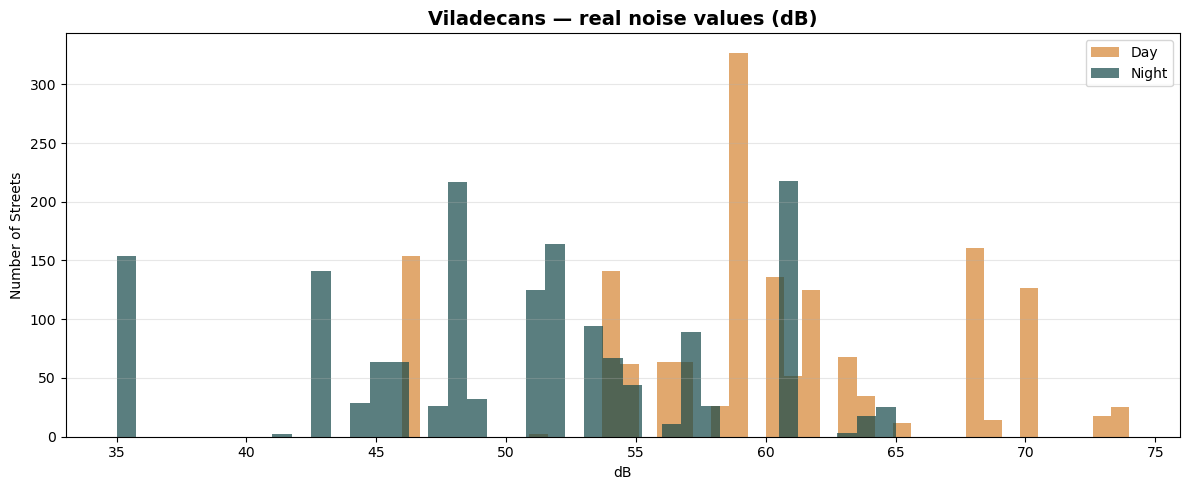

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(roads_regre['noise_day'], bins=40, color='#d58430', alpha=0.7, label='Day')
ax.hist(roads_regre['noise_night'], bins=40, color='#144849', alpha=0.7, label='Night')
ax.set_title('Viladecans — real noise values (dB)', fontsize=14, fontweight='bold')
ax.set_xlabel('dB')
ax.set_ylabel('Number of Streets')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Export to CSV

In [6]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
roads_regre.to_csv(os.path.join(output_dir, "osm_roads_noise_regre.csv"), index=False)
print("Exported osm_roads_noise_regre.csv")

Exported osm_roads_noise_regre.csv
